# 08. Şarap Kimyasıyla Denetimsiz Kümeleme

**Kategori:** Kümeleme  
**Gerçek veri seti:** UCI Wine  
**Veri kaynağı:** [https://archive.ics.uci.edu/dataset/109/wine](https://archive.ics.uci.edu/dataset/109/wine)  
**Amaç:** Etiketleri modele göstermeden kimyasal ölçümlerdeki doğal grupları keşfetmek.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Veri ve EDA

In [2]:
from sklearn.datasets import load_wine
d = load_wine(as_frame=True)
df = d.frame.copy()
display(df.head())
print("Boyut:", df.shape, "| Eksik:", int(df.isna().sum().sum()))
display(df.describe().T.round(2))

Boyut: (178, 14) | Eksik: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.00,0.81,11.03,12.36,13.05,13.68,14.83
malic_acid,178.0,2.34,1.12,0.74,1.60,1.87,3.08,5.80
ash,178.0,2.37,0.27,1.36,2.21,2.36,2.56,3.23
alcalinity_of_ash,178.0,19.49,3.34,10.60,17.20,19.50,21.50,30.00
magnesium,178.0,99.74,14.28,70.00,88.00,98.00,107.00,162.00
total_phenols,178.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88
flavanoids,178.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08
nonflavanoid_phenols,178.0,0.36,0.12,0.13,0.27,0.34,0.44,0.66
proanthocyanins,178.0,1.59,0.57,0.41,1.25,1.56,1.95,3.58
color_intensity,178.0,5.06,2.32,1.28,3.22,4.69,6.20,13.00


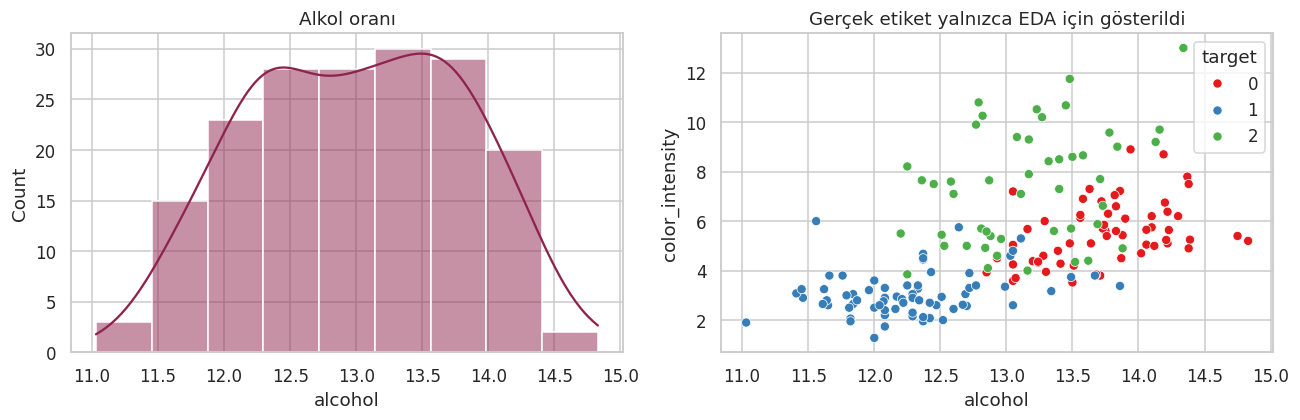

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.alcohol, kde=True, ax=axes[0], color="#8E244D")
axes[0].set(title="Alkol oranı")
sns.scatterplot(data=df, x="alcohol", y="color_intensity", hue="target",
                palette="Set1", ax=axes[1])
axes[1].set(title="Gerçek etiket yalnızca EDA için gösterildi")
plt.tight_layout(); plt.show()

## 2. Standardizasyon, k seçimi ve dış doğrulama

In [4]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

X, y_true = d.data, d.target
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
k_values = range(2, 7)
models = {k: KMeans(n_clusters=k, n_init=40, random_state=RANDOM_STATE).fit(X_scaled)
          for k in k_values}
evaluation = pd.DataFrame({
    "k": list(k_values),
    "silhouette": [silhouette_score(X_scaled, models[k].labels_) for k in k_values],
    "ARI_sadece_sonradan": [adjusted_rand_score(y_true, models[k].labels_) for k in k_values],
})
display(evaluation.round(3))

,k,silhouette,ARI_sadece_sonradan
0,2,0.259,0.374
1,3,0.285,0.897
2,4,0.259,0.765
3,5,0.232,0.647
4,6,0.237,0.639


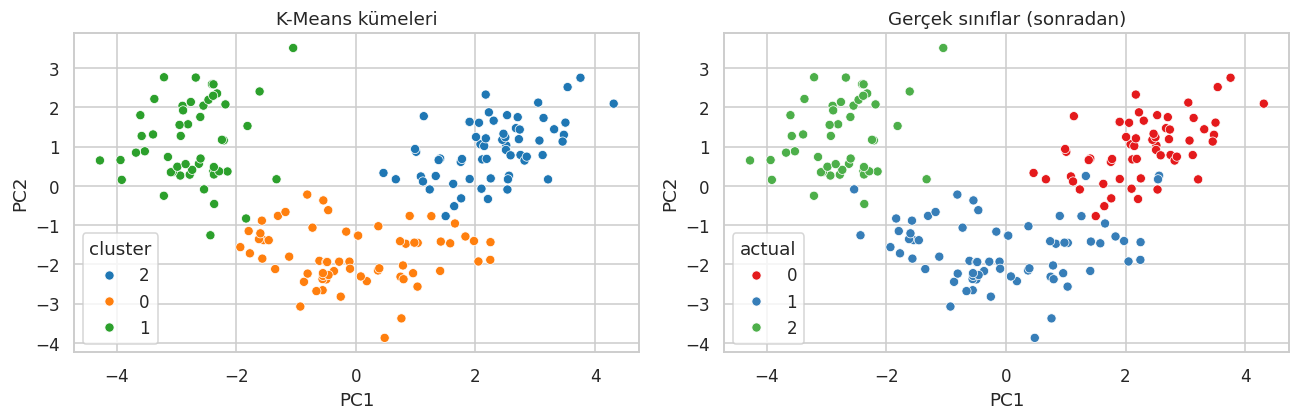

In [5]:
best_k = int(evaluation.loc[evaluation.silhouette.idxmax(), "k"])
best_model = models[best_k]
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_scaled)
coords = pca.transform(X_scaled)
plot_df = pd.DataFrame(coords, columns=["PC1", "PC2"]).assign(
    cluster=best_model.labels_.astype(str), actual=y_true.astype(str)
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster", ax=axes[0], palette="tab10")
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="actual", ax=axes[1], palette="Set1")
axes[0].set_title("K-Means kümeleri"); axes[1].set_title("Gerçek sınıflar (sonradan)")
plt.tight_layout(); plt.show()
joblib.dump({"scaler": scaler, "model": best_model, "pca": pca,
             "best_k": best_k, "features": d.feature_names, "evaluation": evaluation},
            MODEL_DIR / "08_sarap_kumeleme.joblib")
json.dump({"best_k": best_k, "silhouette": float(evaluation.silhouette.max()),
           "ARI": float(adjusted_rand_score(y_true, best_model.labels_))},
          open(RESULT_DIR / "08_sarap_kumeleme.json", "w"), indent=2)

## Sonuç

K-Means gerçek sınıfları eğitimde görmedi. `silhouette` içsel küme kalitesini, ARI ise yalnızca
analiz sonunda mevcut gerçek çeşit etiketleriyle benzerliği ölçtü. Böylece denetimsiz öğrenme ile
etiketli değerlendirme birbirine karıştırılmadı.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **K-Means ile grupları bulma** biçimindedir.
Bu notebookta **ölçekleme, silhouette ile k seçimi, PCA ve gerçek etiketlerle yalnızca sonradan ARI kontrolü** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).